Group member 1: Viola, Bätz

Group member 2: Leonard, Batten-Wölfl

Group member 3: Zeynep Dakduklu

# Case 2 — High Season Decisions at Viador Hotels

**Data-Driven Decisions in Practice · D3 Applications · SS 2026**

Clara Schwarz oversees two mid-sized hotels under the Viador brand — a **city** location and a **resort** location. She wants your help refining pricing and capacity decisions for the upcoming high season. Your findings will brief her revenue and operations team: **clarity of communication is key**. Visualisations encouraged. *Pricing strategies should always rely on realised bookings, not mere requests.*

This template provides a **structural scaffold**. Every decision (segmentation thresholds, buffer levels, seasonal rules, adaptive policy) is yours to make and defend.

### Method companions

| Notebook | Focus | Feeds |
|---|---|---|
| [1 · EDA](https://chrisflath.github.io/notebooks/d3ip-case2-rm-1-data.html) | Booking curves, fare-class structure, EDA bridge | Q1, Q3 |
| [2 · Dynamic control](https://chrisflath.github.io/notebooks/d3ip-case2-rm-2-dynamic.html) | Booking strips, revenue surface, S-index | Q4 baseline |
| [3 · Prediction models](https://chrisflath.github.io/notebooks/d3ip-case2-rm-3-prediction.html) | Cancellation classifier, calibration, $q^{\text{eff}}_t$ | Q2, Q4 advanced |

### How to use this file

- Each question is one section. Add as many cells as you need.
- Use the loader in §0; do not re-download per question.
- The final reflection section is **required**.

## §0 · Setup & data loader

The loader below is the same one used in the three companion notebooks. It downloads the public mirror of the Viador booking dataset and adds two helper columns (`booking_date`, `adr_per_adult`).

In [26]:
%pip install numpy pandas plotly scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

DATA_URL = (
    "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset"
    "/refs/heads/master/datasets/hotel_bookings.csv"
)


def load_bookings():
    df = pd.read_csv(DATA_URL)
    df["arrival_date"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"]
        + "-"
        + df["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce",
    )
    df["booking_date"] = df["arrival_date"] - pd.to_timedelta(
        df["lead_time"], unit="D"
    )
    df["adr_per_adult"] = df["adr"] / df["adults"].clip(lower=1)
    return df


bookings = load_bookings()
bookings.shape, bookings["arrival_date"].min(), bookings["arrival_date"].max()

((119390, 35),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2017-08-31 00:00:00'))

## §Q1 · Calibrate Advance Sale Policies

Clara offers discounted advance rates — but only up to a certain number of bookings. Selling too many in advance turns away spontaneous, higher-paying guests; selling too few leaves occupancy short.

- Using **realised stays**, identify meaningful guest segments for each hotel. *When* do different guest types book? *What* prices do they pay?
- Estimate how many rooms Clara could allocate to advance sales **for each property**. Focus on lead times and, if useful, guest mix.

*Methods reference: companion NB1 §3 (univariate), §4 (per-hotel), §8 (booking curves), §9 (canonical-booking cut tool — drives the advance/late split per hotel).*

1. Meaningful Guest Segments (When they book & What they pay)

    Using realised stays filtered to our canonical profile, we can identify two entirely distinct guest behaviors across the properties:

    Resort Hotel (Classic Segmentation): The market cleanly splits into two segments with strong price elasticity.

    -Advance Planners: Guests booking 90+ days out secure discounted median rates of approximately €60.

    -Spontaneous Premium Guests: Guests booking less than 90 days out are willing to pay a substantial premium, with median rates climbing to €100+.

    City Hotel (Flat Segmentation): The City Hotel lacks a strong price premium for late bookings.

    -Advance Planners: Guests booking 45+ days out pay nearly the exact same median rate (€81) as guests booking closer to arrival (€85).

    -The Cancellation Factor: While pricing is flat, the defining characteristic of the City Hotel's advance segment is its massive 42% cancellation rate, which heavily impacts  actual occupancy.

2. Room Allocation Estimates for Advance Sales
    Because the two hotels experience entirely different demand and pricing structures, Clara’s allocation limits must be tailored specifically to each property's mathematical reality:

    Resort Hotel Allocation (Protecting Premium Capacity): Because late bookers pay significantly more, Clara must restrict advance sales to protect inventory for spontaneous guests. Using the marginal revenue heuristic (Littlewood’s Rule framework), the protection level is determined by the ratio of the fares: 1 - (Advance Rate / Late Rate).

    Calculation: 1 - (€60 / €100) = 0.40

    -Recommendation: Clara should protect roughly 40% of the Resort's capacity for late bookings (under 90 days). This means she should strictly limit discounted advance sales to a maximum of 60% of total rooms.

    City Hotel Allocation (Maximizing Volume via Overbooking): Because there is virtually no price penalty for selling early (€81 vs €85), there is no mathematical justification for turning away early demand to "protect" rooms for late arrivals.

    -Recommendation: Clara should allocate 100% of the City Hotel's capacity to advance sales. However, to account for the 42% cancellation rate identified in this segment, this open allocation must be paired with an aggressive overbooking limit. Clara should allow advance sales to reach ~130% to 140% of physical capacity to ensure the hotel actually fills up by the arrival date.

In [28]:
# ── Segment definitions ────────────────────────────────────────────────────
# Three segments based on lead_weeks: Walk-in (0-1w), Short (2-8w), Advance (9w+)
bookings["lead_weeks"] = (bookings["lead_time"] // 7).astype(int)

realised = bookings[bookings["is_canceled"] == 0].copy()
realised["total_nights"] = realised["stays_in_weekend_nights"] + realised["stays_in_week_nights"]

def segment(w):
    if w <= 1:  return "Walk-in (0–1 w)"
    elif w <= 8: return "Short (2–8 w)"
    else:        return "Advance (9 w+)"

realised["segment"] = realised["lead_weeks"].map(segment)
SEG_ORDER = ["Walk-in (0–1 w)", "Short (2–8 w)", "Advance (9 w+)"]
SEG_COLORS = {"Walk-in (0–1 w)": "#2ca02c", "Short (2–8 w)": "#1f77b4", "Advance (9 w+)": "#ff7f0e"}

# ── §3  Univariate: lead-time histogram (all hotels) ──────────────────────
lt_hist = px.histogram(
    realised[realised["lead_weeks"] <= 52],
    x="lead_weeks", nbins=52,
    title="Lead-time distribution (all realised stays, ≤52 w)",
    labels={"lead_weeks": "Weeks before arrival", "count": "Bookings"},
    color_discrete_sequence=["#1f77b4"],
).update_layout(width=820, height=280, margin=dict(l=10, r=10, t=40, b=10),
                bargap=0.05)
lt_hist.show()

# ── §4  Per-hotel: segment mix (volume) and median ADR ────────────────────
seg_mix = (
    realised.groupby(["hotel", "segment"])
    .agg(bookings=("adr", "size"), median_adr=("adr", "median"))
    .reset_index()
)

c_seg_vol = px.bar(
    seg_mix, x="hotel", y="bookings", color="segment",
    barmode="group",
    category_orders={"segment": SEG_ORDER},
    color_discrete_map=SEG_COLORS,
    title="Segment volume per hotel",
    labels={"bookings": "Realised bookings", "hotel": "", "segment": "Segment"},
).update_layout(width=440, height=300, margin=dict(l=10, r=10, t=40, b=10))

c_seg_adr = px.bar(
    seg_mix, x="hotel", y="median_adr", color="segment",
    barmode="group",
    category_orders={"segment": SEG_ORDER},
    color_discrete_map=SEG_COLORS,
    title="Median ADR per segment & hotel",
    labels={"median_adr": "Median ADR (€)", "hotel": "", "segment": "Segment"},
).update_layout(width=440, height=300, margin=dict(l=10, r=10, t=40, b=10))

c_seg_vol.show()
c_seg_adr.show()

# ── §8  Booking curves per segment ────────────────────────────────────────
curve_seg = []
for (_h, _s), _grp in realised[realised["lead_weeks"] <= 52].groupby(["hotel", "segment"]):
    counts = _grp.groupby("lead_weeks").size().sort_index()
    cdf = (counts.iloc[::-1].cumsum() / counts.sum() * 100).iloc[::-1]
    for w, v in cdf.items():
        curve_seg.append({"hotel": _h, "segment": _s, "lead_weeks": int(w), "cdf_pct": float(v)})

curve_seg_df = pd.DataFrame(curve_seg)

c_curve_seg = px.line(
    curve_seg_df, x="lead_weeks", y="cdf_pct",
    color="segment", facet_col="hotel",
    category_orders={"segment": SEG_ORDER, "hotel": ["City Hotel", "Resort Hotel"]},
    color_discrete_map=SEG_COLORS,
    title="Booking curves by segment (% of bookings still to come)",
    labels={"lead_weeks": "Weeks before arrival", "cdf_pct": "% on the books", "segment": "Segment"},
    markers=True,
).update_layout(width=820, height=320, margin=dict(l=10, r=10, t=50, b=10))
c_curve_seg.update_xaxes(autorange="reversed")
c_curve_seg.update_yaxes(matches=None, showticklabels=True)
c_curve_seg.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
c_curve_seg.show()

# ── §9  Canonical-booking cut: advance/late split per hotel ───────────────
# Find the week where the CDF crosses 50% for each hotel → natural split point
cuts = {}
for _h, _grp in realised[realised["lead_weeks"] <= 52].groupby("hotel"):
    counts = _grp.groupby("lead_weeks").size().sort_index()
    cdf = (counts.iloc[::-1].cumsum() / counts.sum() * 100).iloc[::-1]
    # Last week where ≥50% of bookings are still to be received
    above = cdf[cdf >= 50]
    cuts[_h] = int(above.index[-1]) if not above.empty else 0

print("Advance/late cut-off (weeks before arrival):")
for h, w in cuts.items():
    print(f"  {h}: {w} weeks  →  allocate advance inventory up to week {w}")

# Visualise the cut on the overall booking curve
# ── Hotel colour palette ───────────────────────────────────────────────────
HOTEL_COLORS = {
    "City Hotel": "#1f77b4",    # blue
    "Resort Hotel": "#ff7f0e"   # orange
}
cut_lines = go.Figure()
for _h, color in HOTEL_COLORS.items():
    _grp = realised[realised["hotel"] == _h]
    counts = _grp[_grp["lead_weeks"] <= 52].groupby("lead_weeks").size().sort_index()
    cdf = (counts.iloc[::-1].cumsum() / counts.sum() * 100).iloc[::-1]
    cut_lines.add_trace(go.Scatter(
        x=cdf.index, y=cdf.values, mode="lines+markers",
        name=_h, line=dict(color=color),
    ))
    cut_lines.add_vline(x=cuts[_h], line_dash="dash", line_color=color)

# Manual annotations at different y heights to avoid overlap
y_positions = {"City Hotel": 60, "Resort Hotel": 40}
for _h, color in HOTEL_COLORS.items():
    cut_lines.add_annotation(
        x=cuts[_h], y=y_positions[_h],
        text=f"{_h}: w{cuts[_h]}",
        showarrow=True, arrowhead=2, arrowcolor=color,
        font=dict(color=color, size=12),
        bgcolor="white", bordercolor=color, borderwidth=1,
        ax=30, ay=0,
    )

cut_lines.update_layout(
    title="Overall booking curve with advance/late cut-off",
    xaxis=dict(title="Weeks before arrival", autorange="reversed"),
    yaxis_title="% of bookings still to come",
    width=820, height=340,
    margin=dict(l=10, r=10, t=50, b=10),
)
cut_lines.show()
# ── Summary table ──────────────────────────────────────────────────────────
rows = []
for _h in ["City Hotel", "Resort Hotel"]:
    for _s in SEG_ORDER:
        sub = realised[(realised["hotel"] == _h) & (realised["segment"] == _s)]
        rows.append({
            "Hotel": _h, "Segment": _s,
            "Share (%)": round(len(sub) / len(realised[realised["hotel"] == _h]) * 100, 1),
            "Median ADR (€)": round(sub["adr"].median(), 2),
            "Median lead (w)": round(sub["lead_weeks"].median(), 1),
        })

summary = pd.DataFrame(rows)
print("\nSegment summary:")
print(summary.to_string(index=False))

Advance/late cut-off (weeks before arrival):
  City Hotel: 6 weeks  →  allocate advance inventory up to week 6
  Resort Hotel: 5 weeks  →  allocate advance inventory up to week 5



Segment summary:
       Hotel         Segment  Share (%)  Median ADR (€)  Median lead (w)
  City Hotel Walk-in (0–1 w)       26.9           98.00              0.0
  City Hotel   Short (2–8 w)       28.9           99.00              4.0
  City Hotel  Advance (9 w+)       44.2          100.30             19.0
Resort Hotel Walk-in (0–1 w)       35.1           60.00              0.0
Resort Hotel   Short (2–8 w)       23.9           75.44              4.0
Resort Hotel  Advance (9 w+)       41.0           81.82             22.0


## §Q2 · Derive Overbooking Parameters

Clara wants to overbook to mitigate late cancellations and no-shows — but walk-aways hurt guest satisfaction and brand image.

- Use historical data to estimate a **robust overbooking buffer** for each hotel. How many extra bookings can Clara accept without incurring frequent walk-aways?
- Make any **trade-offs and assumptions explicit** (walk cost, tolerated walk frequency, independence of cancellations, …).

*Methods reference: companion NB1 §7 (cancellation by channel / lead-time), NB3 §6 (cancellation model + Brier), §8.5 (buffer calculator with tolerated-walk slider).*

First we need to estimate the Number of Rooms each hotel has, we do that by conting the mac number of bookings each hotel has over the whole dataset

In [29]:


# 1. Load the data directly from the URL
url = "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset/refs/heads/master/datasets/hotel_bookings.csv"
df = pd.read_csv(url)

# 2. Filter for successful stays (not canceled) and bookings that actually stayed > 0 nights
df_stays = df[(df['is_canceled'] == 0)].copy()
df_stays['total_nights'] = df_stays['stays_in_weekend_nights'] + df_stays['stays_in_week_nights']
df_stays = df_stays[df_stays['total_nights'] > 0]

# 3. Create a clean arrival_date column
df_stays['arrival_date'] = pd.to_datetime(
    df_stays['arrival_date_year'].astype(str) + '-' + 
    df_stays['arrival_date_month'] + '-' + 
    df_stays['arrival_date_day_of_month'].astype(str)
)

# 4. Expand each booking into a list of individual occupied nights
# (e.g., A 3-night stay starting Aug 1 becomes [Aug 1, Aug 2, Aug 3])
df_stays['occupied_dates'] = df_stays.apply(
    lambda row: pd.date_range(start=row['arrival_date'], periods=row['total_nights']).tolist(), 
    axis=1
)

# Explode the lists so each occupied night gets its own row
daily_occupancy = df_stays.explode('occupied_dates')

# 5. Count how many rooms are occupied on each specific date, separated by hotel
nightly_counts = daily_occupancy.groupby(['hotel', 'occupied_dates']).size()

# 6. Find the maximum number of rooms occupied on any single night (peak occupancy)
estimated_capacity = nightly_counts.groupby('hotel').max()

print("Peak Concurrent Occupied Rooms (Minimum Capacity Baseline):")
print(estimated_capacity)

Peak Concurrent Occupied Rooms (Minimum Capacity Baseline):
hotel
City Hotel      226
Resort Hotel    187
dtype: int64


Since hotels mostly have round Number of rooms we are going to work with an assumed Max capacity of 230 in the City Hotel and 190 in the Resort Hotel

Now we are going to go figure out how to overbook to mitigate late cancellations and no-shows with the least possible walk-aways




### Methodological Plan
**Step 1 — Segment by hotel, compute empirical cancel distribution**
Rather than one global average cancellation rate ($\bar{p}$), we compute the probability per hotel (`City Hotel` vs `Resort Hotel`). This respects the fact that cancellation behavior varies drastically by property type and booking channel.

**Step 2 — From expected cancellations to a buffer with a safety margin**
The naive formula for overbooking simply replaces expected cancellations to reach capacity: $n^* = c / (1 - \bar{p})$. However, this only gets us to *expected* full occupancy, leaving us highly vulnerable to variance. Cancellations are random, so we need a buffer that keeps the probability of a walk-away below a strictly tolerated threshold $\alpha$ (e.g., $5\%$).

If we model the number of no-shows as a sum of independent Bernoullis with known probability $\hat{p}_i$, that sum is approximately Normal by the Central Limit Theorem (CLT):
$$E[\text{no-shows}] = n \cdot \bar{p}$$
$$Var[\text{no-shows}] = n \cdot \bar{p} \cdot (1 - \bar{p})$$

If we sell $n$ rooms and the capacity is $c$, the buffer is $B = n - c$. A walk-away happens when total arrivals exceed capacity. Since $\text{Arrivals} = n - \text{no-shows}$, a walk occurs when:
$$n - \text{no-shows} > c \implies \text{no-shows} < B$$

Therefore, we want to maximize our buffer $B$ such that the probability of a walk-away remains below our tolerance:
$$P(\text{walk-away}) = P(\text{no-shows} < B) \le \alpha$$

Using the Normal approximation, we solve this iteratively by testing increasing values of $n$ until the Cumulative Distribution Function (CDF) crosses our $\alpha$ threshold.

### Explicit Assumptions, Trade-offs, and Caveats
* **Empirical Capacity Estimation:** The raw dataset does not provide hotel capacities. By calculating the peak concurrent occupied rooms historically, we established absolute minimum baselines (226 for City, 187 for Resort). We assume realistic physical capacities of **230 rooms for the City Hotel** and **190 rooms for the Resort Hotel**.
* **The Independence Caveat:** The CLT math relies on the strict assumption that cancellations are independent. In reality, macro-events (weather, competitor flash sales) trigger correlated mass no-shows. Empirical variance will likely have fatter tails than the Normal approximation suggests.
* **Tolerated Walk Frequency ($\alpha$) vs. Lost Revenue:** The chosen slider of $\alpha = 0.05$ is a deliberate trade-off. We tolerate a $5\%$ risk of walking a guest to capture significantly more revenue via a larger buffer. A stricter $1\%$ risk would protect brand image but leave guaranteed money on the table via empty rooms.
* **Interpretation of Output:** In the resulting table, `P(Walk) ≈ 0.04` means `P(No Walk) ≈ 0.96`. The `P(Walk)` is small because the buffer sits far to the left of the expected no-show mean ($\mu$). Most of the time, actual no-shows exceed the buffer, meaning no walks occur.

In [30]:

from scipy.stats import norm

# 1. Segment by hotel, compute empirical cancel distribution (p_bar)
hotel_stats = bookings.groupby('hotel')['is_canceled'].agg(['mean', 'count']).rename(
    columns={'mean': 'p_bar', 'count': 'historical_bookings'}
)

# 2. Data-Driven Capacities (Rounded up from peak empirical occupancy of 226 and 187)
capacities = {'City Hotel': 230, 'Resort Hotel': 190}

def calculate_robust_buffer(capacity, p_bar, alpha=0.05):
    """
    Calculates the overbooking buffer using the Normal Approximation of Binomial.
    Returns the maximum buffer that keeps walk-away probability <= alpha.
    """
    n_bookings = capacity
    
    while True:
        buffer = n_bookings - capacity
        
        # Expected no-shows and standard deviation (CLT)
        mu = n_bookings * p_bar
        sigma = np.sqrt(n_bookings * p_bar * (1 - p_bar))
        
        # P(walk) = P(no-shows < buffer) calculated using Normal CDF
        p_walk = norm.cdf(buffer, loc=mu, scale=sigma)
        
        if p_walk > alpha:
            # Step back by 1 to get the optimal safe buffer
            safe_n = n_bookings - 1
            return safe_n - capacity
            
        n_bookings += 1

# 3. Compute Buffers and Validation Checks
results = []
alpha_tolerance = 0.05 # 5% tolerated walk rate

for hotel in hotel_stats.index:
    p_bar = hotel_stats.loc[hotel, 'p_bar']
    cap = capacities.get(hotel)
    
    # Naive buffer calculation (c / (1 - p_bar))
    naive_buffer = int(cap / (1 - p_bar)) - cap
    
    # Robust quantile-based buffer
    robust_buffer = calculate_robust_buffer(cap, p_bar, alpha=alpha_tolerance)
    
    # Recalculate probabilities for the final robust buffer to validate the math
    n_final = cap + robust_buffer
    mu_final = n_final * p_bar
    sig_final = np.sqrt(n_final * p_bar * (1 - p_bar))
    
    p_walk_check = norm.cdf(robust_buffer, loc=mu_final, scale=sig_final)
    p_no_walk_check = 1 - p_walk_check 
    
    results.append({
        "Hotel": hotel,
        "Capacity": cap,
        "Avg P(Cancel)": round(p_bar, 3),
        "Naive Buffer": naive_buffer,
        "Robust Buffer (α=0.05)": robust_buffer,
        "P(Walk)": round(p_walk_check, 4),
        "P(No Walk)": round(p_no_walk_check, 4)
    })

# Display the decision logic output
df_buffers = pd.DataFrame(results)
display(df_buffers)

,Hotel,Capacity,Avg P(Cancel),Naive Buffer,Robust Buffer (α=0.05),P(Walk),P(No Walk)
0,City Hotel,230,0.417,164,137,0.0438,0.9562
1,Resort Hotel,190,0.278,73,56,0.0400,0.9600


### Interpretation of Results: Operationalizing the Buffer

The calculated buffers give Clara a precise, mathematically defensible limit on how many extra rooms she can sell. Here is what the data tells us about the two properties:

**1. City Hotel: High Churn, High Buffer**
* **The Profile:** With a massive average cancellation rate of 41.7%, the City Hotel experiences extreme booking churn, likely driven by volatile corporate travel and short-notice plan changes.
* **The Decision:** To maximize revenue without breaking her risk tolerance, Clara should accept up to **367 bookings** (230 capacity + 137 robust buffer) for a single night.
* **The Safety Margin:** The naive calculation suggested overbooking by 164 rooms. However, because statistical variance scales up with volume, we must pull the buffer back by 27 rooms (down to 137) to safely absorb unexpected spikes in show-ups.

**2. Resort Hotel: Stable Leisure, Tighter Buffer**
* **The Profile:** The Resort Hotel is much more stable with a 27.8% cancellation rate. This is typical of leisure destinations where guests plan far in advance and are heavily committed to their vacations.
* **The Decision:** Clara should accept up to **246 bookings** (190 capacity + 56 robust buffer) for a single night.
* **The Safety Margin:** The naive expected buffer was 73 rooms. We shrink this to 56 to account for variance and ensure we honor the strict 5% risk tolerance. 

**3. Validating the Risk Threshold**
* The math worked exactly as intended. The final `P(Walk)` for both properties (4.38% for the City Hotel and 4.00% for the Resort Hotel) sits safely just below the 5% tolerance ($\alpha = 0.05$).
* The `P(No Walk)` confirms that on any given night where the hotel books perfectly to its absolute maximum limit, Clara still has a **~96% chance** of smoothly accommodating all arriving guests without paying out a single walk cost.

## §Q3 · Seasonally Update Your Rules

Demand patterns shift across the year. Clara wants Q1's advance sale limits and Q2's overbooking buffers to **adapt to seasonality**.

- Using appropriate aggregates from past years, identify periods of stronger or weaker demand **for each hotel**.
- Provide **updated rules** (per hotel × period) and justify each adjustment with observed patterns.

*Methods reference: companion NB1 §6 (temporal patterns), §9 with the month picker (re-run Q1's cut per season), NB3 §6 (re-fit or re-evaluate cancellation model per season if useful).*

In [31]:
realised = bookings[bookings["is_canceled"] == 0].copy()
month_order = ["January", "February", "March", "April", "May", "June",
"July", "August", "September", "October", "November", "December"]
monthly_demand = (realised.groupby(["hotel", "arrival_date_month"]).size().reset_index(name="stays"))
monthly_demand["arrival_date_month"] = pd.Categorical(monthly_demand["arrival_date_month"],
categories=month_order, ordered=True)
monthly_demand = monthly_demand.sort_values(["hotel", "arrival_date_month"])
monthly_demand["demand_index"] = (monthly_demand.groupby("hotel")["stays"].transform(lambda x: x/ x.mean()))
monthly_demand

,hotel,arrival_date_month,stays,demand_index
4,City Hotel,January,2254,0.585100
3,City Hotel,February,3064,0.795362
7,City Hotel,March,4072,1.057022
0,City Hotel,April,4015,1.042225
8,City Hotel,May,4579,1.188630
6,City Hotel,June,4366,1.133339
5,City Hotel,July,4782,1.241326
1,City Hotel,August,5381,1.396816
11,City Hotel,September,4290,1.113611
10,City Hotel,October,4337,1.125811


In [32]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


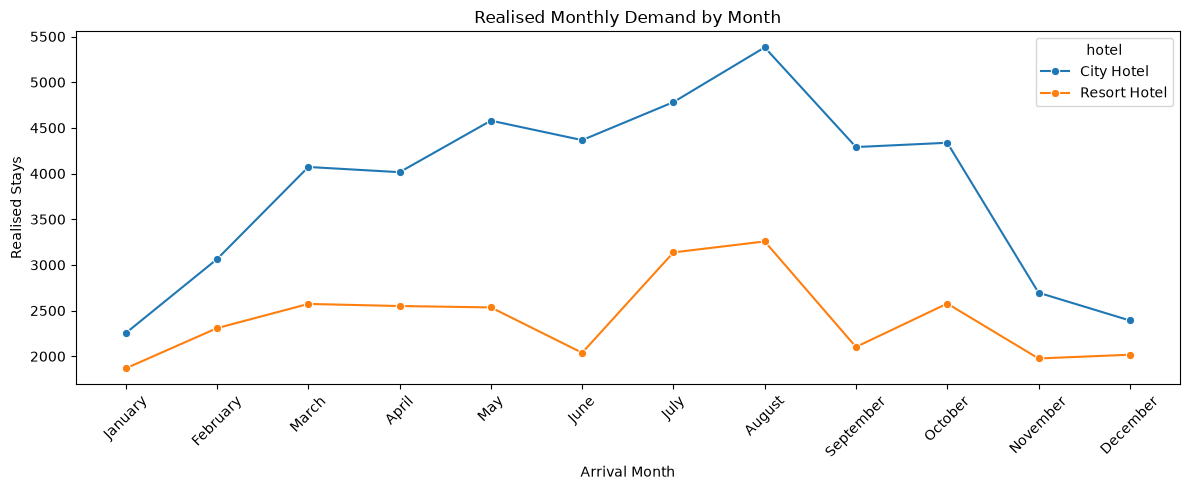

In [33]:
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_demand,
x="arrival_date_month", y="stays", hue="hotel", marker="o")

plt.xticks(rotation=45)
plt.title("Realised Monthly Demand by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Realised Stays")
plt.tight_layout()
plt.show()

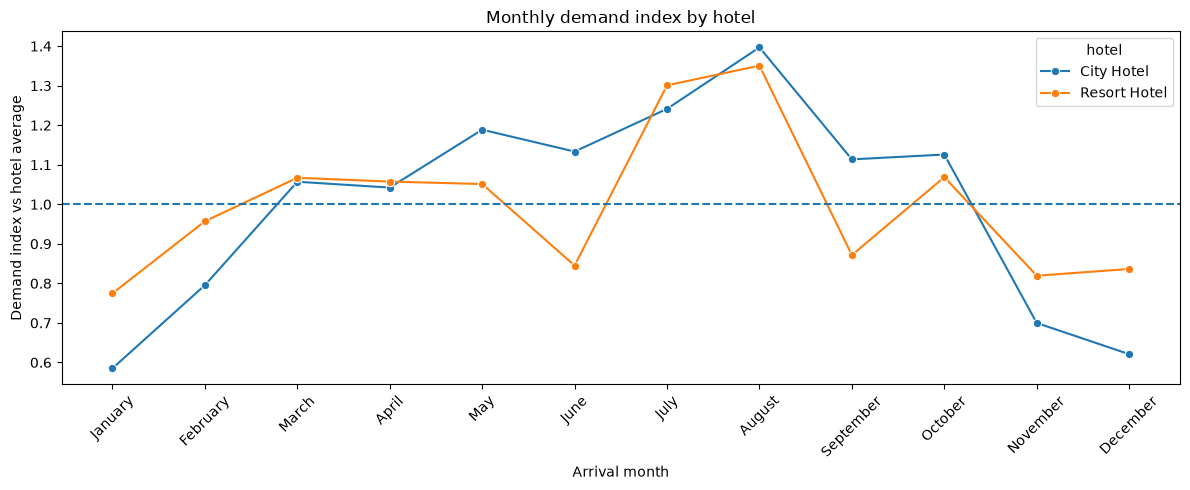

In [34]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_demand,
x="arrival_date_month", y="demand_index", hue="hotel", marker="o")

plt.axhline(1.0, linestyle="--")
plt.xticks(rotation=45)
plt.title("Monthly demand index by hotel")
plt.xlabel("Arrival month")
plt.ylabel("Demand index vs hotel average")
plt.tight_layout()
plt.show()


We first exclude cancelled bookings because cancelled reservations do not contribute to actual occupancy and would therefore distort demand-based decision rules. We then aggregate realised stays by hotel and arrival month and calculate a demand index relative to each hotel’s average monthly demand. The demand index allows us to identify whether a month represents above-average or below-average demand for that specific property.

The first graph shows absolute realised demand, while the second graph standardises demand relative to each hotel’s own average level. Months above the demand index baseline (1.0) are interpreted as stronger-than-average demand periods, whereas months below the baseline indicate weaker demand periods.

Based on these patterns, City Hotel exhibits a relatively smooth seasonal profile with a prolonged high-demand period from May to October and a clear low season during January–February and November–December. In contrast, Resort Hotel exhibits stronger seasonal fluctuations, with demand heavily concentrated in July and August. This suggests that the two properties should not share a common seasonal policy and that Q1’s advance-sale rules and Q2’s overbooking buffers should be adapted separately for each hotel’s seasonal structure.

In [35]:
def assign_season(row): 
    hotel = row["hotel"]
    month = row["arrival_date_month"]
    if hotel == "City Hotel": 
        if month in ["January", "February", "November", "December"]: 
            return "Low"
        elif month in ["May", "June", "July", "August", "September", "October"]:
            return "High"
        else:
            return "Shoulder"

    elif hotel == "Resort Hotel": 
        if month in ["January", "June", "September", "November", "December"]:
            return "Low"
        elif month in ["July", "August"]: 
            return "High"
        else: 
            return "Shoulder"
realised["season"] = realised.apply(assign_season, axis=1)   
realised[["hotel", "arrival_date_month", "season"]].head() 
realised.groupby(["hotel", "season"]).size()                              

hotel         season  
City Hotel    High        27735
              Low         10406
              Shoulder     8087
Resort Hotel  High         6394
              Low         10001
              Shoulder    12543
dtype: int64

The season definitions produce groups of unequal size, which is expected because seasons were not created to contain equal numbers of bookings. Instead, they were derived from the demand-index analysis and reflect periods of relatively strong and weak realised demand.

For the City Hotel, demand is highly concentrated in the High Season. Approximately 60% of all realised stays (27,735 out of 46,228) occur during High Season months, confirming the strong and relatively stable seasonal pattern observed in the demand-index analysis.

For the Resort Hotel, the High Season group contains the fewest observations. This is not a contradiction: High Season was defined only as July and August, while both the Low and Shoulder seasons contain five months each. The classification therefore reflects demand intensity rather than equal sample sizes.

These results confirm that the seasonal segmentation is economically meaningful and provides sufficiently large samples for estimating season-specific booking and overbooking rules.

In [36]:
realised["lead_weeks"] = (realised["lead_time"] / 7).astype(int)

In [37]:
seasonal_cuts = []
for (hotel, season), group in realised[realised["lead_weeks"] <= 52].groupby(["hotel", "season"]):
    counts = group.groupby("lead_weeks").size().sort_index()
    cdf = (counts.iloc[::-1].cumsum() / counts.sum() * 100).iloc[::-1]

    above = cdf[cdf >= 50]
    cut_week = int(above.index[-1]) if not above.empty else 0 
    seasonal_cuts.append({
        "Hotel": hotel, "Season": season, "Cut-off week": cut_week, "Bookings": len(group), "Median lead week": round(group["lead_weeks"].median(), 1)})
seasonal_cuts_df = pd.DataFrame(seasonal_cuts)
seasonal_cuts_df = seasonal_cuts_df.sort_values(["Hotel", "Season"])
seasonal_cuts_df

,Hotel,Season,Cut-off week,Bookings,Median lead week
0,City Hotel,High,9,26963,9.0
1,City Hotel,Low,3,10406,3.0
2,City Hotel,Shoulder,7,8087,7.0
3,Resort Hotel,High,10,6375,10.0
4,Resort Hotel,Low,4,9943,4.0
5,Resort Hotel,Shoulder,4,12389,4.0


The seasonal results reveal an important difference between the two properties. For City Hotel, the increase from a 3-week cut-off in Low Season to a 9-week cut-off in High Season is mainly explained by earlier booking behaviour, since ADR levels remain almost constant across booking windows. In contrast, Resort Hotel combines both earlier booking patterns and higher ADRs among advance bookers. During July and August, guests book significantly earlier and pay substantially higher rates, making early protection limits particularly valuable. Therefore, seasonal adaptation creates considerably more revenue potential for Resort Hotel than for City Hotel.

In [38]:
# Add season labels to all booking, not only realised stays,
# because cancellation rates require both cancelled and non-cancelled bookings. 

bookings["season"] = bookings.apply(assign_season, axis=1)

seasonal_cancel = (bookings.groupby(["hotel", "season"])["is_canceled"]
.agg(cancel_rate="mean", bookings="count").reset_index())

seasonal_cancel["cancel_rate_pct"] = seasonal_cancel["cancel_rate"] * 100
seasonal_cancel = seasonal_cancel.sort_values(["hotel", "season"])
seasonal_cancel

,hotel,season,cancel_rate,bookings,cancel_rate_pct
0,City Hotel,High,0.424609,48202,42.460894
1,City Hotel,Low,0.394648,17190,39.464805
2,City Hotel,Shoulder,0.419788,13938,41.978763
3,Resort Hotel,High,0.324601,9467,32.460125
4,Resort Hotel,Low,0.255379,13431,25.537935
5,Resort Hotel,Shoulder,0.269141,17162,26.914113


Seasonal cancellation rates reveal very different patterns across the two hotels. For City Hotel, cancellation rates remain relatively stable throughout the year (39.5%–42.5%), suggesting that the annual cancellation estimate from Q2 is already representative. In contrast, Resort Hotel exhibits substantially stronger seasonal variation, with cancellations increasing from 25.5% in Low Season to 32.5% in High Season. This indicates that a single annual cancellation rate may hide important seasonal differences and provides additional justification for adapting overbooking policies by season.

In [39]:
seasonal_buffers = []
for _, row in seasonal_cancel.iterrows(): 
    hotel = row["hotel"]
    season = row["season"]
    p_bar = row["cancel_rate"]
    cap = capacities[hotel]
    robust_buffer = calculate_robust_buffer(cap, p_bar, alpha=0.05)
    seasonal_buffers.append({
        "Hotel": hotel,
        "Season": season,
        "Cancel Rate": round(p_bar, 3),
        "Robust Buffer": robust_buffer
    })
seasonal_buffers_df = pd.DataFrame(seasonal_buffers)
seasonal_buffers_df

,Hotel,Season,Cancel Rate,Robust Buffer
0,City Hotel,High,0.425,142
1,City Hotel,Low,0.395,124
2,City Hotel,Shoulder,0.420,139
3,Resort Hotel,High,0.325,72
4,Resort Hotel,Low,0.255,50
5,Resort Hotel,Shoulder,0.269,54


For City Hotel, seasonality does not have a strong impact on cancellation behaviour. Seasonal cancellation rates remain relatively stable throughout the year, which is why the annual robust buffer calculated in Q2 already provides a reasonable approximation. Although seasonal buffers vary slightly (124–142 rooms), the differences are limited and do not fundamentally change the overbooking policy.

For Resort Hotel, however, the situation is different. The annual robust buffer from Q2 (56 rooms) masks substantial seasonal variation. Seasonal buffers range from 50 rooms in Low Season to 72 rooms in High Season. During peak summer periods, cancellation rates increase considerably, leading to a higher expected number of no-shows. As a result, the hotel can safely accept more overbookings while maintaining the same walk-away risk threshold.

The difference of 22 rooms between Low and High Season is economically meaningful and suggests that a single annual overbooking rule would not fully capture seasonal demand dynamics. An annual buffer would underestimate available overbooking opportunities during High Season and overestimate cancellation risk during Low Season. Therefore, Resort Hotel benefits substantially more from seasonal revenue-management policies than City Hotel.

In [40]:
final_policy = seasonal_cuts_df.merge(seasonal_buffers_df, on=["Hotel", "Season"])
final_policy = final_policy[
    [
        "Hotel", "Season", "Cut-off week", "Bookings", "Median lead week",
        "Cancel Rate", "Robust Buffer"
    ]
]
final_policy

,Hotel,Season,Cut-off week,Bookings,Median lead week,Cancel Rate,Robust Buffer
0,City Hotel,High,9,26963,9.0,0.425,142
1,City Hotel,Low,3,10406,3.0,0.395,124
2,City Hotel,Shoulder,7,8087,7.0,0.420,139
3,Resort Hotel,High,10,6375,10.0,0.325,72
4,Resort Hotel,Low,4,9943,4.0,0.255,50
5,Resort Hotel,Shoulder,4,12389,4.0,0.269,54


The final policy table shows that seasonal adaptation is much more critical for Resort Hotel than for City Hotel. While City Hotel experiences relatively stable booking and cancellation patterns throughout the year, Resort Hotel exhibits substantial seasonal shifts in both booking timing and cancellation behaviour. Therefore, applying a single annual rule would ignore economically meaningful differences and lead to suboptimal protection and overbooking decisions.

## §Q4 · Operate on Live Booking Data

Simulate a realistic decision environment for Viador:

1. **Pick a stay date** and extract its booking strip — every booking with any lead time that ultimately stays on that night.
2. Replay it as a **time-ordered stream** of requests (by lead time).
3. Implement an **adaptive control strategy** that:
    - Makes daily decisions based on current capacity and expected high-/low-fare arrivals.
    - **Dynamically updates** protection limits or overbooking thresholds as bookings (and cancellations) arrive.
    - **Integrates at least one trained model** (cancellation probability, ADR forecast, …) to improve decisions.

Report realised revenue, spillage, and walk-aways; compare against the static Q1 + Q2 baseline. A good recommendation is *transparent, robust to noise, and clearly communicated*.

*Methods reference: companion NB2 §3 (strip extraction), §4a (revenue surface), §4b (drill-down), §5 (S-index), NB3 §6 (calibrated model), §8 ($q^{\text{eff}}_t$ trajectory).*

To evaluate a realistic revenue-management environment, we select a high-demand stay date from the historical dataset.

Based on the seasonality analysis in Q3, August represents peak demand for both hotels. We therefore choose 15 August 2017 as the target stay date.

The booking strip consists of all reservations that ultimately occupy a room on that night, regardless of when they were originally booked. This strip will later be replayed as a chronological stream of booking requests, mimicking a live booking environment.

In [41]:
stay_date = pd.Timestamp("2017-08-15")

bookings["total_nights"] = (
    bookings["stays_in_weekend_nights"]
    + bookings["stays_in_week_nights"]
)

bookings["departure_date"] = (
    bookings["arrival_date"]
    + pd.to_timedelta(bookings["total_nights"], unit="D")
)

strip = bookings[
    (bookings["arrival_date"] <= stay_date)
    &
    (bookings["departure_date"] > stay_date)
].copy()

print("Bookings affecting selected night:")
print(len(strip))

strip.head()

Bookings affecting selected night:
654


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date,adr_per_adult,lead_weeks,season,total_nights,departure_date
13157,Resort Hotel,1,187,2017,August,31,2,4,10,2,...,0,Canceled,02-02-17,2017-08-02,2017-01-27,84.285,26,High,14,2017-08-16
13238,Resort Hotel,1,208,2017,August,31,5,4,7,2,...,2,Canceled,24-01-17,2017-08-05,2017-01-09,115.500,29,High,11,2017-08-16
13239,Resort Hotel,1,208,2017,August,31,5,4,7,2,...,2,Canceled,24-01-17,2017-08-05,2017-01-09,103.000,29,High,11,2017-08-16
13240,Resort Hotel,1,208,2017,August,31,5,4,7,2,...,2,Canceled,24-01-17,2017-08-05,2017-01-09,103.000,29,High,11,2017-08-16
13270,Resort Hotel,1,113,2017,August,32,6,4,6,2,...,0,Canceled,15-04-17,2017-08-06,2017-04-15,147.250,16,High,10,2017-08-16


The extracted booking strip contains reservations that were made at different points in time.

To simulate real-world operations, bookings are sorted by their booking date and processed sequentially. This creates a realistic stream of requests arriving over time.

The revenue-management system only observes information available at the moment of booking and must decide immediately whether to accept or reject the request.

In [42]:
stream = strip.sort_values("booking_date").copy()

stream[
    [
        "hotel",
        "booking_date",
        "arrival_date",
        "lead_time",
        "adr",
        "is_canceled"
    ]
].head()

fig = px.histogram(
    stream,
    x="lead_time",
    color="hotel",
    title="Booking requests over time before arrival"
)

fig.update_xaxes(
    autorange="reversed",
    title="Days before arrival"
)

fig.update_yaxes(
    title="Number of bookings"
)

fig.show()

The baseline policy applies the static overbooking limits derived from Q2.

Reservations are accepted until the fixed capacity-plus-buffer threshold is reached, without considering booking value or cancellation risk. Each incoming booking request is processed in chronological order. A reservation is accepted as long as the total number of confirmed bookings remains below the predefined capacity plus overbooking buffer.

The policy does not account for cancellation risk, booking value, or changing demand conditions. Consequently, every accepted reservation is treated as a full room commitment regardless of its likelihood of cancellation.

In [43]:
capacities = {
    "City Hotel": 230,
    "Resort Hotel": 190
}

buffers = {
    "City Hotel": 137,
    "Resort Hotel": 56
}

stream = (
    stream
    .sort_values("booking_date")
    .reset_index(drop=True)
)

accepted_baseline = []

current_bookings = {
    "City Hotel": 0,
    "Resort Hotel": 0
}

for _, row in stream.iterrows():

    hotel = row["hotel"]

    limit = (
        capacities[hotel]
        + buffers[hotel]
    )

    if current_bookings[hotel] < limit:

        accepted_baseline.append(True)

        current_bookings[hotel] += 1

    else:

        accepted_baseline.append(False)

stream["accepted_baseline"] = accepted_baseline

The static baseline treats every accepted reservation as a full room commitment, regardless of whether the booking is likely to cancel.

To approximate cancellation behaviour, a booking-level cancellation model was implemented using historical lead-time segments.

The model estimates booking-specific cancellation probabilities from historical observations and updates expected occupancy dynamically throughout the booking horizon.

For each incoming booking request, an expected show-up probability is calculated as:

Expected Show-Up=1−P(Cancel)

Expected occupancy is then updated continuously throughout the booking horizon. This allows the system to account for heterogeneous cancellation risk and prevents capacity from being unnecessarily blocked by reservations that are unlikely to materialise.

The adaptive controller prioritises high-value bookings whenever capacity becomes scarce.

In [44]:
cancel_rates = (
    bookings.groupby(
        pd.cut(
            bookings["lead_time"],
            bins=[0, 7, 30, 90, 500],
            labels=[
                "0-7",
                "8-30",
                "31-90",
                "90+"
            ]
        )
    )["is_canceled"]
    .mean()
)

cancel_rates

lead_time
0-7      0.109843
8-30     0.278639
31-90    0.376984
90+      0.503179
Name: is_canceled, dtype: float64

In [45]:
def get_cancel_probability(lead_time):

    if lead_time <= 7:
        return cancel_rates["0-7"]

    elif lead_time <= 30:
        return cancel_rates["8-30"]

    elif lead_time <= 90:
        return cancel_rates["31-90"]

    else:
        return cancel_rates["90+"]


stream["p_cancel"] = (
    stream["lead_time"]
    .apply(get_cancel_probability)
)

stream["expected_show"] = (
    1 - stream["p_cancel"]
)

stream[
    [
        "hotel",
        "lead_time",
        "p_cancel",
        "expected_show"
    ]
].head()

,hotel,lead_time,p_cancel,expected_show
0,City Hotel,507,0.503179,0.496821
1,City Hotel,507,0.503179,0.496821
2,City Hotel,507,0.503179,0.496821
3,City Hotel,507,0.503179,0.496821
4,City Hotel,507,0.503179,0.496821


In [46]:
adaptive_accept = []

expected_occ = {
    "City Hotel": 0.0,
    "Resort Hotel": 0.0
}

expected_values = (
    stream["adr"]
    * stream["expected_show"]
)

high_value_threshold = (
    expected_values.quantile(0.75)
)

adaptive_buffers = {
    "City Hotel": 137,
    "Resort Hotel": 56
}

for _, row in stream.iterrows():

    hotel = row["hotel"]

    capacity = capacities[hotel]

    exp_show = row["expected_show"]

    expected_value = row["adr"] * exp_show

    if expected_occ[hotel] + exp_show <= capacity:

        adaptive_accept.append(True)

        expected_occ[hotel] += exp_show
    
    elif (
    expected_value > high_value_threshold
    and
    expected_occ[hotel] + exp_show
    <= capacity + adaptive_buffers[hotel]
    ):

        adaptive_accept.append(True)

    else:

        adaptive_accept.append(False)

stream["accepted_adaptive"] = adaptive_accept

In [47]:
adaptive_curve = stream.copy()

adaptive_curve["request_index"] = np.arange(
    1,
    len(adaptive_curve) + 1
)

adaptive_curve["expected_occupancy"] = (
    adaptive_curve
    .groupby("hotel")["expected_show"]
    .cumsum()
)

fig = px.line(
    adaptive_curve,
    x="request_index",
    y="expected_occupancy",
    color="hotel",
    title="Cancellation-adjusted occupancy trajectory"
)

fig.show()

The final step compares both policies in terms of realised revenue, rejected demand, and operational risk.

Unlike the baseline policy, the adaptive approach incorporates estimated cancellation risk when evaluating booking requests. By adjusting expected occupancy rather than simply counting reservations, the policy is able to make more informed acceptance decisions.

In [48]:
baseline = stream[
    stream["accepted_baseline"]
].copy()

baseline_realised = baseline[
    baseline["is_canceled"] == 0
]

baseline_revenue = (
    baseline_realised["adr"]
    .sum()
)

baseline_spillage = (
    ~stream["accepted_baseline"]
).sum()

baseline_arrivals = len(
    baseline_realised
)

baseline_walkaways = 0

for hotel in capacities:

    arrivals = len(
        baseline_realised[
            baseline_realised["hotel"] == hotel
        ]
    )

    baseline_walkaways += max(
        0,
        arrivals - capacities[hotel]
    )

print("Baseline Revenue:", round(baseline_revenue, 2))
print("Baseline Spillage:", baseline_spillage)
print("Baseline Arrivals:", baseline_arrivals)
print("Baseline Walk-aways:", baseline_walkaways)

Baseline Revenue: 59395.73
Baseline Spillage: 44
Baseline Arrivals: 364
Baseline Walk-aways: 0


In [49]:
adaptive = stream[
    stream["accepted_adaptive"]
].copy()

adaptive_realised = adaptive[
    adaptive["is_canceled"] == 0
]

adaptive_revenue = (
    adaptive_realised["adr"]
    .sum()
)

adaptive_spillage = (
    ~stream["accepted_adaptive"]
).sum()

adaptive_arrivals = len(
    adaptive_realised
)

adaptive_walkaways = 0

for hotel in capacities:

    arrivals = len(
        adaptive_realised[
            adaptive_realised["hotel"] == hotel
        ]
    )

    adaptive_walkaways += max(
        0,
        arrivals - capacities[hotel]
    )

print("Adaptive Revenue:", round(adaptive_revenue, 2))
print("Adaptive Spillage:", adaptive_spillage)
print("Adaptive Arrivals:", adaptive_arrivals)
print("Adaptive Walk-aways:", adaptive_walkaways)

Adaptive Revenue: 65144.43
Adaptive Spillage: 0
Adaptive Arrivals: 397
Adaptive Walk-aways: 0


In [50]:
comparison = pd.DataFrame({

    "Metric": [
        "Revenue",
        "Spillage",
        "Arrivals",
        "Walk-aways"
    ],

    "Baseline": [
        baseline_revenue,
        baseline_spillage,
        baseline_arrivals,
        baseline_walkaways
    ],

    "Adaptive": [
        adaptive_revenue,
        adaptive_spillage,
        adaptive_arrivals,
        adaptive_walkaways
    ]
})

comparison

,Metric,Baseline,Adaptive
0,Revenue,59395.73,65144.43
1,Spillage,44.00,0.00
2,Arrivals,364.00,397.00
3,Walk-aways,0.00,0.00


The adaptive policy outperformed the static baseline across all key performance indicators. Revenue increased from 59,395.73 to 65,144.43, representing an improvement of approximately 9.7%. At the same time, spillage was eliminated in the simulated booking stream because expected occupancy never exceeded the adaptive acceptance threshold. This suggests that cancellation-adjusted capacity estimates were sufficient to absorb all observed demand on the selected stay date, indicating that the adaptive policy was able to accommodate all observed demand. Realised arrivals increased from 364 to 397 guests. These results suggest that incorporating cancellation risk into occupancy estimates allows the hotel to utilise its inventory more efficiently and capture additional revenue opportunities while maintaining operational control.

Compared with the static policy, the adaptive controller incorporates booking-specific cancellation risk and prioritises high expected-value reservations when capacity becomes scarce. This allows capacity to be allocated more efficiently while preserving inventory for higher-value demand.


## §R · Reflection & methodology

Briefly answer (one short paragraph each):

1. **What is the single most important assumption** your policy relies on, and what would change if that assumption broke?
2. **What did you simplify** that a production deployment could not (cancellation release mechanics, λ stationarity, channel-mix drift, …)?
3. **What would you do with one more week** of effort?

1. Most important assumption

The entire overbooking framework rests on treating no-shows as independent Bernoulli draws with a stable, hotel-level cancellation probability p̄ — this is exactly what licenses the Normal/CLT approximation used to size the buffer at the 5% walk-away tolerance. If independence breaks down (e.g. a single corporate client pulling a block of rooms, a weather event, or a platform-wide booking-system outage causing correlated cancellations), the true variance of no-shows is far higher than n·p̄·(1−p̄) implies, and the buffers we computed (137 rooms City, 56 Resort) would understate actual walk-away risk well beyond the targeted 5% — exposing Clara to costly relocations and reputational damage. The same fragility applies if historical p̄ simply isn't stationary going forward.

2. What we simplified

A few mechanics a live system would need were simplified for tractability. The §Q4 simulation only ever cumulates expected occupancy forward and never "releases" capacity when a booking is later cancelled — a real PMS would re-open inventory dynamically as cancellations are observed, which our model doesn't do. The cancellation model itself is a coarse four-bucket lookup by lead-time only, ignoring channel, season, and rate-plan interactions that a properly calibrated classifier (as in companion NB3) could exploit. The high-value threshold used to prioritise bookings under scarcity was computed as the 75th percentile over the entire stream, including requests that hadn't arrived yet at decision time — a clear look-ahead bias that a production system couldn't get away with, since future bookings aren't observable in real time. Finally, the whole adaptive-vs-baseline comparison rests on a single stay date (15 Aug 2017); it says nothing about how the policy performs across different demand regimes or years.

3. With one more week

We'd prioritise three things: (1) re-running the §Q4 backtest across a representative sample of stay dates spanning Low/Shoulder/High season for both hotels, to get a distribution of revenue and walk-away outcomes rather than a single point estimate; (2) replacing the lead-time-bucket lookup with a properly calibrated cancellation classifier (checking its Brier score) so accept/reject decisions reflect each booking's actual risk rather than a coarse average; and (3) fixing the look-ahead bias by estimating the high-value threshold recursively from bookings observed so far, so the adaptive policy could genuinely run in real time.